# Week 5 — Day 3: Build & Ship
# The Titanic Data Explorer
### Code to AI — Python & Data Science (from Zero to Portfolio)
**Instructor:** Ali Hasnain — Lead AI Engineer & CTO

---

## Today we build a real project

No new syntax today. Everything we use, you already know. What is new is the **process**:

> Ask a question → answer it with code → write down what it means → ship it.

That loop is the entire job of a data analyst. Today you do it for the first time.

## What you will learn
1. How to frame a dataset as a set of **questions**
2. How to answer each one with the tools from Day 1 and Day 2
3. How to write an **insight** (not just a number)
4. How to structure a repo and write a README that sells your work
5. How to push it to GitHub

**Session plan (75 minutes)**

| Time | Section |
|------|---------|
| 0:00 – 0:05 | Recap + cheat sheet |
| 0:05 – 0:12 | Framing: from data to questions |
| 0:12 – 0:50 | Build the explorer together (Q1 to Q5) |
| 0:50 – 0:58 | One chart |
| 0:58 – 0:68 | Writing insights + README |
| 0:68 – 0:75 | Push to GitHub + demos + assignment |


## 1. Recap — your Week 5 toolkit

Everything you need today is on this one card.

```python
# Load & look
df = sns.load_dataset("titanic")
df.head()   df.shape   df.info()   df.describe()   df.isna().sum()

# Select
df["age"]                 df[["age","fare"]]
df.loc[0:3]               df.iloc[0:3]

# Filter
df[df["age"] > 30]
df[(df["sex"]=="female") & (df["survived"]==1)]
df[df["class"].isin(["First","Second"])]
df[df["age"].between(13,19)]

# Sort
df.sort_values(by="fare", ascending=False)
df.nlargest(5, "fare")

# Columns
df = df.copy()
df["new"] = df["a"] + df["b"]

# Group
df.groupby("sex")["survived"].mean()
df.groupby(["sex","class"])["survived"].mean()
df.groupby("class")["fare"].agg(["count","mean","max"])
```

That is it. Ten commands. With those ten you can interrogate almost any table in the world.

## 2. Framing: from data to questions

Here is the mistake almost every beginner makes:

> They open a dataset, run `.describe()`, stare at it, and think *"now what?"*

The fix is simple: **decide your questions before you write code.**

A dataset is not interesting. A **question** is interesting. The data is just how you answer it.

### The Titanic story

On 15 April 1912, the Titanic sank. About 2,200 people were aboard. Around 1,500 died.

Our dataset has 891 of those passengers. For each one we know: their age, their sex,
their ticket class, what they paid, who they travelled with — and whether they lived.

So the question that makes this dataset worth opening is:

> **Who survived the Titanic, and why?**

That is too big to answer in one line. So we break it into five small questions
that code *can* answer:

| # | Question |
|---|----------|
| **Q1** | How many people survived overall? |
| **Q2** | Did your **sex** change your chances? |
| **Q3** | Did your **class** change your chances? |
| **Q4** | Did your **age** change your chances? |
| **Q5** | Did the **fare** you paid change your chances? |

Now we have a plan. Let's build.

---
# THE TITANIC DATA EXPLORER
---

## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

# Load the data
titanic = sns.load_dataset("titanic")

print("Titanic Data Explorer")
print("=" * 40)
print(f"Passengers in dataset: {titanic.shape[0]}")
print(f"Columns of information: {titanic.shape[1]}")

Titanic Data Explorer
Passengers in dataset: 891
Columns of information: 15


## Step 1 — Inspect

Before any analysis: the 5-command ritual. Never skip it. Never.

In [2]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [30]:
# What is missing?
missing = titanic.isna().sum()
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


**Note before we start:** `age` is missing for 177 passengers, and `deck` for most.

We are **not** fixing that today (that is Week 6). But we must be **honest** about it:
any conclusion we draw about age is based on 714 people, not 891.

Good analysts state their limitations. Bad analysts hide them.

In [5]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Q1 — How many survived overall?

Our baseline. Every other number today gets compared to this one.

In [31]:
# Count of survivors and non-survivors
print(titanic["survived"].value_counts())
print()

# The rate. Remember: mean of a 0/1 column = the rate.
overall_rate = titanic["survived"].mean()
print(f"Overall survival rate: {overall_rate:.1%}")

survived
0    549
1    342
Name: count, dtype: int64

Overall survival rate: 38.4%


In [32]:
# In plain numbers
survivors = titanic[titanic["survived"] == 1].shape[0]
died = titanic[titanic["survived"] == 0].shape[0]

print(f"Survived: {survivors}")
print(f"Died    : {died}")
print(f"Total   : {survivors + died}")

Survived: 342
Died    : 549
Total   : 891


### 💡 Insight 1

**About 38% of passengers in this dataset survived. Roughly 2 out of every 3 people aboard died.**

That is our baseline. From here on, the question is: *who beat 38%, and who did worse?*

## Q2 — Did sex change your chances?

The Titanic followed "women and children first." Did it actually happen?
Let's check, instead of assuming.

In [8]:
# How many of each sex?
print(titanic["sex"].value_counts())

sex
male      577
female    314
Name: count, dtype: int64


In [9]:
# Survival rate by sex — one line
by_sex = titanic.groupby("sex")["survived"].mean()
print(by_sex)

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


In [33]:
# The same thing, formatted for a human
for sex, rate in by_sex.items():
    print(f"{sex:8} {rate:.1%}")

female   74.2%
male     18.9%


In [11]:
# A fuller picture: count, survivors, and rate together
sex_summary = titanic.groupby("sex").agg(
    passengers=("survived", "count"),
    survivors=("survived", "sum"),
    survival_rate=("survived", "mean")
)
sex_summary

,passengers,survivors,survival_rate
sex,,,
female,314,233,0.742038
male,577,109,0.188908


### 💡 Insight 2

**Sex was the single strongest factor. About 74% of women survived, against only 19% of men —
women were nearly 4 times more likely to live.**

"Women and children first" was not a slogan. It shows up clearly in the numbers.

## Q3 — Did class change your chances?

The Titanic had three classes. First class was at the top of the ship, near the lifeboats.
Third class was at the bottom. Did that matter?

In [12]:
# Passengers per class
print(titanic["class"].value_counts())

class
Third     491
First     216
Second    184
Name: count, dtype: int64


In [13]:
# Survival rate by class
by_class = titanic.groupby("class")["survived"].mean()

for cls, rate in by_class.items():
    print(f"{cls:8} {rate:.1%}")

First    63.0%
Second   47.3%
Third    24.2%


In [14]:
# Full summary
class_summary = titanic.groupby("class").agg(
    passengers=("survived", "count"),
    survivors=("survived", "sum"),
    survival_rate=("survived", "mean"),
    avg_fare=("fare", "mean")
)
class_summary

,passengers,survivors,survival_rate,avg_fare
class,,,,
First,216,136,0.629630,84.154687
Second,184,87,0.472826,20.662183
Third,491,119,0.242363,13.675550


### Now combine both — sex AND class

This is where groupby earns its keep.

In [15]:
# Survival rate for every combination
titanic.groupby(["sex", "class"])["survived"].mean()

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64

In [16]:
# Formatted so it's readable at a glance
combo = titanic.groupby(["sex", "class"])["survived"].mean()

print("Survival rate by sex and class")
print("=" * 35)
for (sex, cls), rate in combo.items():
    print(f"{sex:8} {cls:8} {rate:6.1%}")

Survival rate by sex and class
female   First     96.8%
female   Second    92.1%
female   Third     50.0%
male     First     36.9%
male     Second    15.7%
male     Third     13.5%


### 💡 Insight 3

**Class mattered enormously: 63% of First class survived versus 24% of Third.
But sex and class together were brutal — a woman in First class had a ~97% chance of
living, while a man in Third class had ~14%. Same ship, same night, seven times the odds.**

Take a moment with that. These are real people. This is what data can show you that
a story cannot.

## Q4 — Did age change your chances?

Here we have to be careful, because 177 ages are missing.

In [17]:
# Be honest about the gap first
known_age = titanic[titanic["age"].notna()]

print(f"Total passengers      : {titanic.shape[0]}")
print(f"With a known age      : {known_age.shape[0]}")
print(f"Age unknown           : {titanic['age'].isna().sum()}")
print()
print("Everything below uses only the passengers whose age we know.")

Total passengers      : 891
With a known age      : 714
Age unknown           : 177

Everything below uses only the passengers whose age we know.


In [18]:
# Average age of survivors vs non-survivors
print("Average age of survivors    :", round(known_age[known_age["survived"] == 1]["age"].mean(), 1))
print("Average age of non-survivors:", round(known_age[known_age["survived"] == 0]["age"].mean(), 1))

Average age of survivors    : 28.3
Average age of non-survivors: 30.6


Barely any difference. That is a **useful non-finding** — averages hide the story here.

Let's split by age band instead.

In [19]:
# Three age bands, using filtering
children = known_age[known_age["age"] < 13]
teens    = known_age[known_age["age"].between(13, 19)]
adults   = known_age[known_age["age"] >= 20]

print("Survival rate by age band")
print("=" * 35)
print(f"Children (under 13) : {children['survived'].mean():.1%}  ({children.shape[0]} people)")
print(f"Teens (13-19)       : {teens['survived'].mean():.1%}  ({teens.shape[0]} people)")
print(f"Adults (20+)        : {adults['survived'].mean():.1%}  ({adults.shape[0]} people)")

Survival rate by age band
Children (under 13) : 58.0%  (69 people)
Teens (13-19)       : 41.1%  (95 people)
Adults (20+)        : 38.4%  (550 people)


In [20]:
# The dataset already has a 'who' column: man / woman / child
titanic.groupby("who").agg(
    passengers=("survived", "count"),
    survival_rate=("survived", "mean")
)

,passengers,survival_rate
who,,
child,83,0.590361
man,537,0.163873
woman,271,0.756458


In [21]:
# Were children in Third class still protected?
children_by_class = children.groupby("class")["survived"].mean()

print("Children's survival rate by class")
print("=" * 35)
for cls, rate in children_by_class.items():
    print(f"{cls:8} {rate:.1%}")

Children's survival rate by class
First    75.0%
Second   100.0%
Third    41.7%


### 💡 Insight 4

**Children under 13 survived at about 58%, well above the 38% baseline — but the
protection was not equal. Children in First and Second class almost all survived,
while only about 42% of Third-class children did.**

**Caution:** this rests on 714 known ages out of 891. If the missing ages were not
random, this number could shift.

## Q5 — Did the fare you paid change your chances?

Fare is really a proxy for wealth. We half-know the answer from Q3, but let's confirm it directly.

In [22]:
# Fare statistics for survivors vs non-survivors
titanic.groupby("survived")["fare"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
survived,,,,,
0,549,22.117887,10.5,0.0,263.0000
1,342,48.395408,26.0,0.0,512.3292


Read that carefully. Survivors paid an average of about **48**, non-survivors about **22** —
more than double.

But look at the **median**: 26 versus 10. The mean is much higher than the median in both
groups, which means a few very expensive tickets are pulling the average up.

Whenever mean and median disagree that much, trust the median more.

In [23]:
# The most expensive tickets — did they all survive?
titanic.nlargest(10, "fare")[["fare", "class", "sex", "age", "survived"]]

,fare,class,sex,age,survived
258,512.3292,First,female,35.0,1
679,512.3292,First,male,36.0,1
737,512.3292,First,male,35.0,1
27,263.0000,First,male,19.0,0
88,263.0000,First,female,23.0,1
341,263.0000,First,female,24.0,1
438,263.0000,First,male,64.0,0
311,262.3750,First,female,18.0,1
742,262.3750,First,female,21.0,1
118,247.5208,First,male,24.0,0


In [24]:
# The cheapest tickets
titanic.nsmallest(10, "fare")[["fare", "class", "sex", "age", "survived"]]

,fare,class,sex,age,survived
179,0.0,Third,male,36.0,0
263,0.0,First,male,40.0,0
271,0.0,Third,male,25.0,1
277,0.0,Second,male,NaN,0
302,0.0,Third,male,19.0,0
413,0.0,Second,male,NaN,0
466,0.0,Second,male,NaN,0
481,0.0,Second,male,NaN,0
597,0.0,Third,male,49.0,0
633,0.0,First,male,NaN,0


In [25]:
# Fare bands, using filtering
cheap  = titanic[titanic["fare"] < 10]
mid    = titanic[titanic["fare"].between(10, 50)]
pricey = titanic[titanic["fare"] > 50]

print("Survival rate by fare band")
print("=" * 40)
print(f"Under 10   : {cheap['survived'].mean():.1%}  ({cheap.shape[0]} people)")
print(f"10 to 50   : {mid['survived'].mean():.1%}  ({mid.shape[0]} people)")
print(f"Over 50    : {pricey['survived'].mean():.1%}  ({pricey.shape[0]} people)")

Survival rate by fare band
Under 10   : 19.9%  (336 people)
10 to 50   : 42.0%  (395 people)
Over 50    : 68.1%  (160 people)


### 💡 Insight 5

**The more you paid, the more likely you lived. Passengers paying over 50 survived at
about 66%; those paying under 10 survived at about 20%. Fare is mostly telling us the
same story as class — wealth bought a place near the lifeboats.**

## One chart

We are not doing visualization properly until Week 7. But Pandas has a `.plot()` method
built in, and one good chart is worth a paragraph.

Let's plot the finding that matters most.

<Axes: title={'center': 'Survival rate by class'}, xlabel='class', ylabel='Survival rate'>

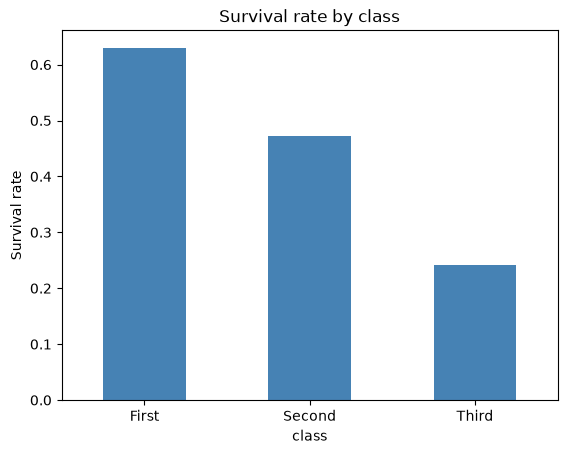

In [26]:
# The simplest chart in Pandas: call .plot() on a Series
by_class = titanic.groupby("class")["survived"].mean()

by_class.plot(
    kind="bar",
    title="Survival rate by class",
    ylabel="Survival rate",
    color="steelblue",
    rot=0
)

<Axes: title={'center': 'Survival rate by sex and class'}, xlabel='sex,class', ylabel='Survival rate'>

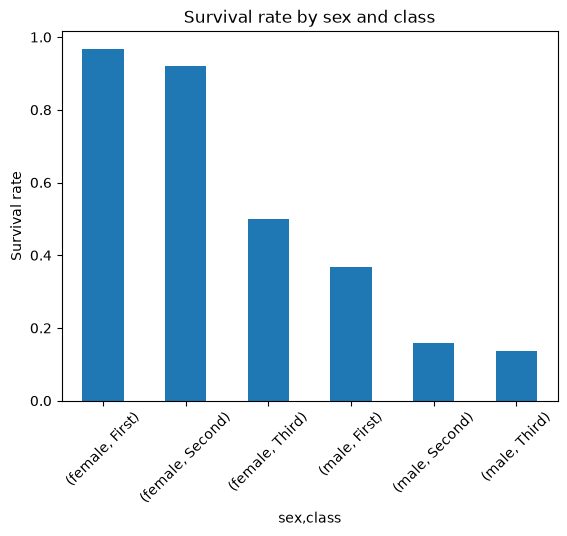

In [27]:
# Sex and class together
titanic.groupby(["sex", "class"])["survived"].mean().plot(
    kind="bar",
    title="Survival rate by sex and class",
    ylabel="Survival rate",
    rot=45
)

<Axes: title={'center': 'Passengers per class'}, xlabel='class', ylabel='Number of passengers'>

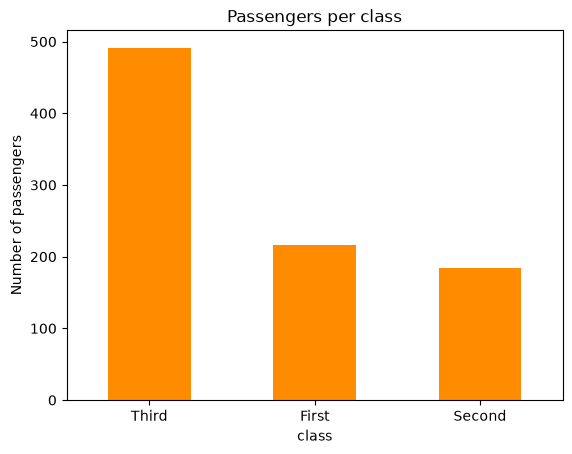

In [28]:
# How many passengers in each class? value_counts plots too.
titanic["class"].value_counts().plot(
    kind="bar",
    title="Passengers per class",
    ylabel="Number of passengers",
    color="darkorange",
    rot=0
)

That is all the plotting we need today. In Week 7 you will learn to make charts that
are genuinely beautiful and tell a story on their own. For now: one bar chart, one point.

**Rule of thumb:** if a chart does not make a point faster than a sentence would, delete it.

## Putting it together — the summary

Let's produce one clean summary of the whole investigation.

In [29]:
print("TITANIC SURVIVAL ANALYSIS")
print("=" * 45)
print(f"Passengers analysed : {titanic.shape[0]}")
print(f"Overall survival    : {titanic['survived'].mean():.1%}")
print()

print("By sex:")
for sex, rate in titanic.groupby("sex")["survived"].mean().items():
    print(f"   {sex:10} {rate:6.1%}")
print()

print("By class:")
for cls, rate in titanic.groupby("class")["survived"].mean().items():
    print(f"   {cls:10} {rate:6.1%}")
print()

print("By who:")
for who, rate in titanic.groupby("who")["survived"].mean().items():
    print(f"   {who:10} {rate:6.1%}")
print()

print("Best odds  : female, First class  -> {:.1%}".format(
    titanic[(titanic["sex"]=="female") & (titanic["class"]=="First")]["survived"].mean()))
print("Worst odds : male, Third class    -> {:.1%}".format(
    titanic[(titanic["sex"]=="male") & (titanic["class"]=="Third")]["survived"].mean()))

TITANIC SURVIVAL ANALYSIS
Passengers analysed : 891
Overall survival    : 38.4%

By sex:
   female      74.2%
   male        18.9%

By class:
   First       63.0%
   Second      47.3%
   Third       24.2%

By who:
   child       59.0%
   man         16.4%
   woman       75.6%

Best odds  : female, First class  -> 96.8%
Worst odds : male, Third class    -> 13.5%


## 📋 Findings — the whole story in five lines

Copy these into your README. This is what a reviewer actually reads.

1. **Only 38% of the 891 passengers in this dataset survived.**
2. **Sex was the strongest single factor — 74% of women lived, against 19% of men.**
3. **Class came second — 63% of First class survived, against 24% of Third.**
4. **Combined, the gap was extreme: a First-class woman had ~97% odds; a Third-class man ~14%.**
5. **Children were protected, but only in the upper classes — Third-class children survived at only about 42%.**

**Limitation:** 177 of 891 ages are missing, so every age-based finding is based on 714 people.

### Notice what makes these good findings
- Each has a **number**
- Each is one **sentence**
- Each says what it **means**, not what code was run
- The limitation is stated **openly**

Nobody is impressed by `groupby`. People are impressed by *"a Third-class man had a 14% chance."*

## 3. Ship it — GitHub

### Repo structure

```
titanic-data-explorer/
├── README.md
├── titanic_explorer.ipynb
└── .gitignore
```

Simple. Clean. A reviewer can understand it in ten seconds.

### The README

This is the most important file in your repo. Most reviewers **never open the notebook** —
they read the README and decide from that.

Structure it as: **Problem → Approach → Result.**

```markdown
# Titanic Data Explorer

Who survived the Titanic, and why? An exploratory analysis of 891 passenger records
using Pandas.

## The question
The Titanic sank on 15 April 1912. This project asks a simple question of the data:
was survival random, or did who you were decide whether you lived?

## The data
891 passenger records: age, sex, ticket class, fare, family aboard, and survival.
Loaded via `seaborn.load_dataset("titanic")`.

## Approach
- Inspected the dataset and documented missing values
- Computed a baseline survival rate
- Compared survival across sex, class, age band, and fare band
- Combined sex and class to find the extremes

## Key findings
1. Only 38% of passengers survived.
2. Sex was the strongest factor: 74% of women survived vs 19% of men.
3. Class came second: 63% of First class vs 24% of Third.
4. Combined, a First-class woman had ~97% odds; a Third-class man ~14%.
5. Children were protected, but mainly in the upper classes.

## Limitation
Age is missing for 177 of 891 passengers, so age-based findings use 714 records.

## Tools
Python · Pandas · Seaborn · Google Colab

## How to run
Open `titanic_explorer.ipynb` in Google Colab and run all cells.
```

### The commands

```bash
git init
git add .
git commit -m "Add Titanic survival analysis with Pandas"
git branch -M main
git remote add origin https://github.com/YOUR-USERNAME/titanic-data-explorer.git
git push -u origin main
```

Or use the GitHub web upload if you prefer — same result.

### Commit message quality

- ❌ `update`
- ❌ `final final v2`
- ✅ `Add survival analysis by sex and class`

Your commit history is public. It is part of your portfolio too.

## 4. Demos (2 minutes each)

Show us:
1. Your repo — README first, not code
2. One finding you are proud of
3. One thing that broke and how you fixed it

That third one is not a punishment. Everyone's code breaks. Being able to say *how you
fixed it* is what makes you employable.

## Your assignment

Open **`week5_day3_assignment.ipynb`**.

You will do this same investigation on a **new dataset** you have not seen —
alone, from a blank notebook, start to finish.

That is the real test. Not whether you can follow along, but whether you can do it
when nobody is showing you.

---

## Wrap-up — what you can do now

Four weeks ago you wrote `print("Hello World")`.

Today you opened a real dataset of 891 people, asked five questions of it, answered
every one with code, and wrote conclusions a historian would recognise as true.

That is not a small thing. That is data science.

### Next week
**Week 6 — Pandas II: Data Cleaning.** Real data is messy: missing values, duplicates,
wrong types, inconsistent text. We stop working with tidy sample data and start fighting
with the real thing.

Push your repo. Post the link. See you next week. 🚀